# Sales Data ETL & Business Analysis

This notebook presents an exploratory business analysis of the Brazilian E-Commerce Public Dataset by Olist.

The objective is to answer common business questions using Python, Pandas and Matplotlib.

# Contents

1. Revenue by State

2. Average Order Value (AOV)

3. Payment Methods Distribution

4. Monthly Revenue Trend

5. Revenue by Product Category

6. Top Customers by Spending

# Sales Business Analysis

This notebook answers business questions using the processed datasets created during the data preparation stage.

In [47]:
# ==================================================
# Import necessary libraries
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

In [48]:
# ==================================================
# Define project paths
# ==================================================

RAW_DIR = Path("../data/raw")

PROCESSED_DIR = Path("../data/processed")

CHARTS_DIR = Path("../charts")

CHARTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [49]:
# ==================================================
# Load processed datasets
# ==================================================

customer_sales = pd.read_csv(
    PROCESSED_DIR / "customer_sales.csv"
)

product_sales = pd.read_csv(
    PROCESSED_DIR / "product_sales.csv" 
)

print("Processed datasets loaded successfully!")

Processed datasets loaded successfully!


# Business Question 1: What is the total revenue generated by each Brazilian state?

This analysis evaluates the geographical distribution of sales across Brazil, identifying the top-performing regional markets and highlighting areas with potential room for growth.

### Analytical Framework
Before writing the code, we structure our pipeline by answering three core questions:
1. **Which dataset?** `customer_sales` (as it contains both the geographical location of the buyers and payment information).
2. **Which columns?** `customer_state` and `payment_value`.
3. **Which metric?** Total revenue per state (calculated as the sum of `payment_value`).

*Note for Stakeholders:* Regional analysis allows logistics and marketing teams to optimize distribution centers and target regional ad spends more efficiently.

In [50]:
# ==================================================
# 1. Revenue by State - Data Preparation
# ==================================================

# Group by state, sum payment values, and sort in descending order
revenue_by_state = (
    customer_sales
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

# Filter and store the top 10 states for the visualization pipeline
top10_revenue_states = revenue_by_state.head(10)

print(top10_revenue_states)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64


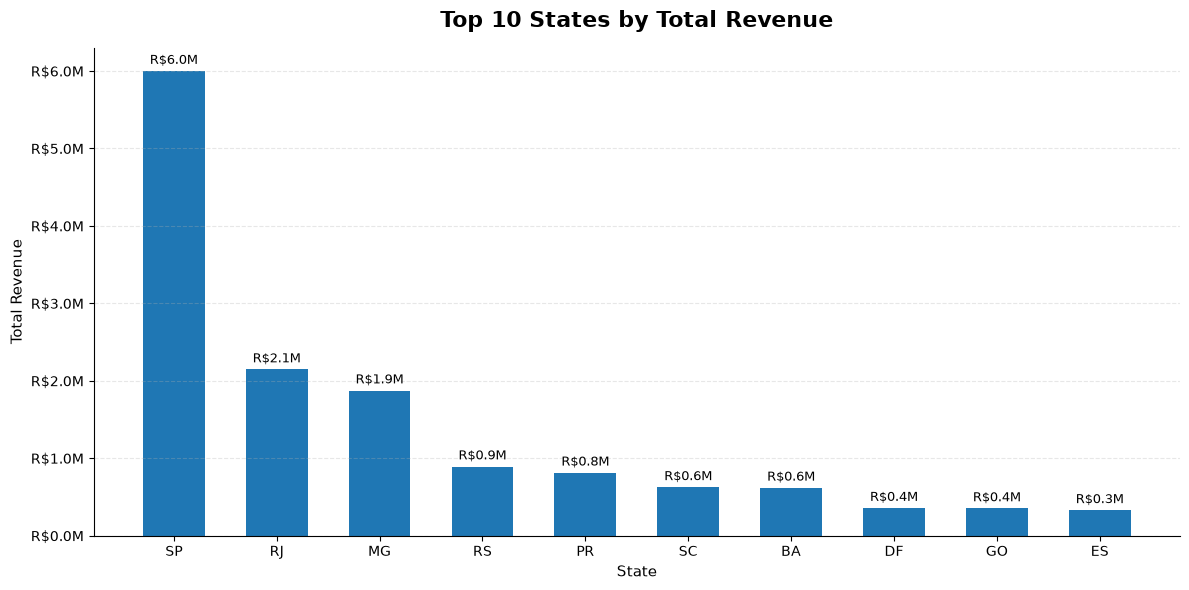

In [51]:
# ==================================================
# 1. Top 10 States by Revenue - Visualization
# ==================================================

# Initialize the plot layout using the Object-Oriented API
fig, ax = plt.subplots(figsize=(12, 6))

# Draw vertical bars using a consistent professional color and width
bars = ax.bar(
    top10_revenue_states.index, 
    top10_revenue_states.values, 
    color="#1f77b4", 
    width=0.6
)

# --------------------------------------------------
# Axis Formatting & Styling (Done before adding text)
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Apply currency formatter in Millions (R$ XX.XM) to the Y-axis using top-level FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R${x/1e6:.1f}M"))

# Ensure X-axis state acronyms are perfectly horizontal and clean
plt.xticks(rotation=0)

# --------------------------------------------------
# Titles, Labels & Annotations
# --------------------------------------------------
ax.set_title("Top 10 States by Total Revenue", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("State", fontsize=11)
ax.set_ylabel("Total Revenue", fontsize=11)

# Add formatted value labels (Millions) symmetrically on top of each vertical bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"R${height/1e6:.1f}M",
        (bar.get_x() + bar.get_width()/2, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# --------------------------------------------------
# Save and Export
# --------------------------------------------------
plt.tight_layout()

# Save the polished chart automatically to the charts directory
plt.savefig(
    CHARTS_DIR / "revenue_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

São Paulo is the leading state in terms of revenue, followed by Rio de Janeiro and Minas Gerais.

These three states account for a significant portion of the company's total sales.

# Business Question 2: What is the Average Order Value (AOV) of the platform?

Average Order Value (AOV) is a critical e-commerce metric that tracks the average amount of money a customer spends each time they place an order. 

### Analytical Framework
Before writing the code, we structure our pipeline by answering three core questions:
1. **Which dataset?** `customer_sales`.
2. **Which columns?** `order_id` and `payment_value`.
3. **Which metric?** Average Order Value.
   * *Formula:* Total Revenue divided by the Total Number of Unique Orders. 

*Note for Stakeholders:* Understanding AOV helps businesses benchmark customer purchasing power and measure the direct impact of pricing strategies, product bundling, or cross-selling campaigns over time.

In [52]:
# ==================================================
# 2. Average Order Value (AOV)
# ==================================================

# Calculate total revenue and unique orders to find the true business AOV
total_revenue_aov = customer_sales["payment_value"].sum()
total_orders_aov = customer_sales["order_id"].nunique()

average_order_value = total_revenue_aov / total_orders_aov

print(f"Average Order Value (AOV): R${average_order_value:.2f}")

Average Order Value (AOV): R$160.99


### Key Insight

The average order value (AOV) provides a baseline for customer spending behavior and can be used to monitor pricing and sales performance over time. By calculating this metric based on unique orders, we ensure an accurate look at the actual ticket size per purchase.

In [53]:
# ==================================================
# Main KPIs Summary
# ==================================================

# 1. Metric Calculations
total_revenue = customer_sales["payment_value"].sum()
total_orders = customer_sales["order_id"].nunique()
total_customers = customer_sales["customer_unique_id"].nunique()
average_order_value = total_revenue / total_orders

# ==================================================
# 2. Main KPIs Summary - Executive Output
# ==================================================

# Define total width of the panel for strict layout alignment
PANEL_WIDTH = 38

print("=" * PANEL_WIDTH)
# The '^' character automatically centers the string within the defined width
print(f"{'ENTERPRISE MAIN KPIS':^{PANEL_WIDTH}}")
print("=" * PANEL_WIDTH)

# Align labels to the left (22 spaces) and numeric counts to the right (16 spaces)
print(f"{'Total Orders:':<22}{total_orders:>16,}")
print(f"{'Total Customers:':<22}{total_customers:>16,}")

# Align financial values to the right (14 spaces) alongside the currency prefix
print(f"{'Total Revenue:':<22}R${total_revenue:>14,.2f}")
print(f"{'Average Order Value:':<22}R${average_order_value:>14,.2f}")
print("=" * PANEL_WIDTH)

         ENTERPRISE MAIN KPIS         
Total Orders:                   99,441
Total Customers:                96,096
Total Revenue:        R$ 16,008,872.12
Average Order Value:  R$        160.99


# Business Question 3: How are payment methods distributed across transactions?

This analysis investigates consumer payment preferences on the platform, evaluating which payment types drive the highest volume and value.

### Analytical Framework
Before writing the code, we structure our pipeline by answering three core questions:
1. **Which dataset?** `customer_sales`.
2. **Which columns?** `payment_type` and `payment_value`.
3. **Which metric?** Total value per payment method (sum of `payment_value`) and the overall percentage share of each transaction type.

*Note for Stakeholders:* Identifying dominant payment methods assists financial operations in negotiating better transaction rates with payment gateways (e.g., credit card companies or local methods like Boleto/Pix).

In [54]:
# ==================================================
# 3. Payment Methods Distribution - Data Preparation
# ==================================================

# Calculate the value counts for each payment type
payment_methods = customer_sales["payment_type"].value_counts()

# CLEANING STEP: Transform snake_case into elegant titles (e.g., credit_card -> Credit Card)
payment_methods.index = payment_methods.index.str.replace("_", " ").str.title()

print(payment_methods)

payment_type
Credit Card    76795
Boleto         19784
Voucher         5775
Debit Card      1529
Not Defined        3
Name: count, dtype: int64


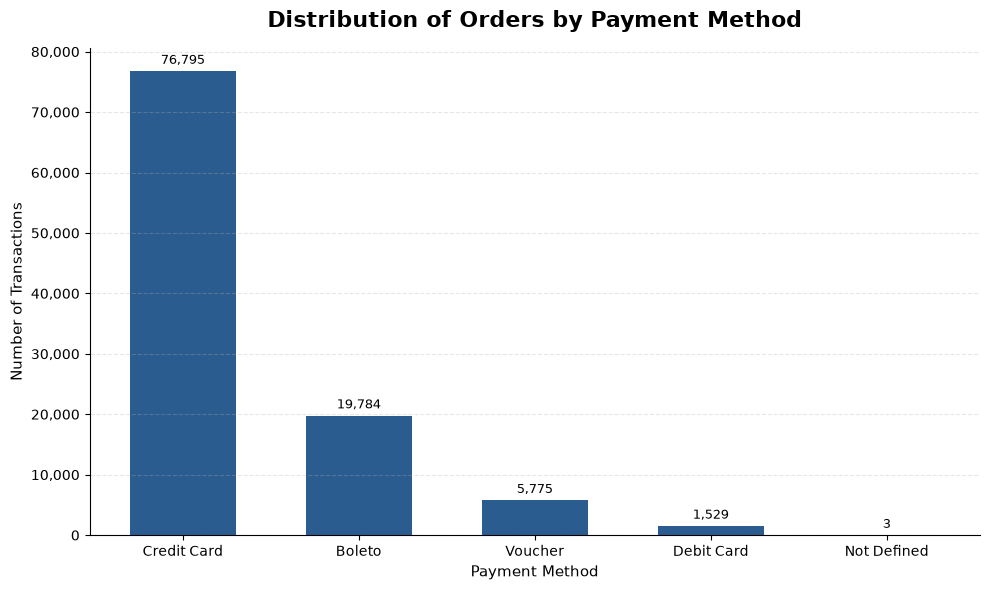

In [55]:
# ==================================================
# 3. Payment Methods Distribution - Visualization
# ==================================================

# Initialize the plot layout using object-oriented API (avoiding plt.figure)
fig, ax = plt.subplots(figsize=(10, 6))

# Draw vertical bars with a professional color and explicit width
bars = ax.bar(payment_methods.index, payment_methods.values, color="#2b5c8f", width=0.6)

# --------------------------------------------------
# Axis Formatting & Styling (Done before adding text)
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Apply thousands formatter to the vertical axis (Y-axis)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

# --------------------------------------------------
# Titles, Labels & Annotations
# --------------------------------------------------
ax.set_title("Distribution of Orders by Payment Method", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Payment Method", fontsize=11)
ax.set_ylabel("Number of Transactions", fontsize=11)

# Ensure X-axis labels are horizontal and clean
plt.xticks(rotation=0)

# Add formatted value labels (integers with thousands separators) on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{int(height):,}",
        (bar.get_x() + bar.get_width()/2, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# --------------------------------------------------
# Save and Export
# --------------------------------------------------
plt.tight_layout()

# Save the polished chart automatically to the charts directory
plt.savefig(
    CHARTS_DIR / "payment_methods_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

Credit cards are the preferred payment method, representing the majority of completed transactions.

Only a negligible number of transactions (3 orders) were classified as "not_defined", indicating minimal data quality issues.

# Business Question 4: What is the monthly revenue trend over time?

This analysis tracks the historical revenue growth timeline of the platform, enabling stakeholders to observe consistent growth trends, cyclical behaviors, or sudden drops.

### Analytical Framework
Before writing the code, we structure our pipeline by answering three core questions:
1. **Which dataset?** `product_sales` or `customer_sales` (ensuring access to order timestamps).
2. **Which columns?** `order_purchase_timestamp` and revenue-related metrics (`payment_value` or `price`).
3. **Which metric?** Monthly Total Revenue (aggregated chronologically by year and month).

*Note for Stakeholders:* Chronological sales tracking is fundamental for identifying seasonal peaks (such as Black Friday or end-of-year holidays) and forecasting future inventory and staffing needs.

In [56]:
# ==================================================
# 4. Monthly Revenue Trend - Data Preparation
# ==================================================

# 1. Ensure purchase timestamp is in datetime format
customer_sales["order_purchase_timestamp"] = pd.to_datetime(customer_sales["order_purchase_timestamp"])

# 2. SMART STEP: Create a clean month column directly as a datetime (first day of each month)
# This bypasses back-and-forth string conversions and keeps temporal alignment perfect for matplotlib
customer_sales["month"] = customer_sales["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

# 3. Group by month and calculate total revenue
monthly_revenue = customer_sales.groupby("month")["payment_value"].sum()

print(monthly_revenue.head())

month
2016-09-01       252.24
2016-10-01     59090.48
2016-12-01        19.62
2017-01-01    138488.04
2017-02-01    291908.01
Name: payment_value, dtype: float64


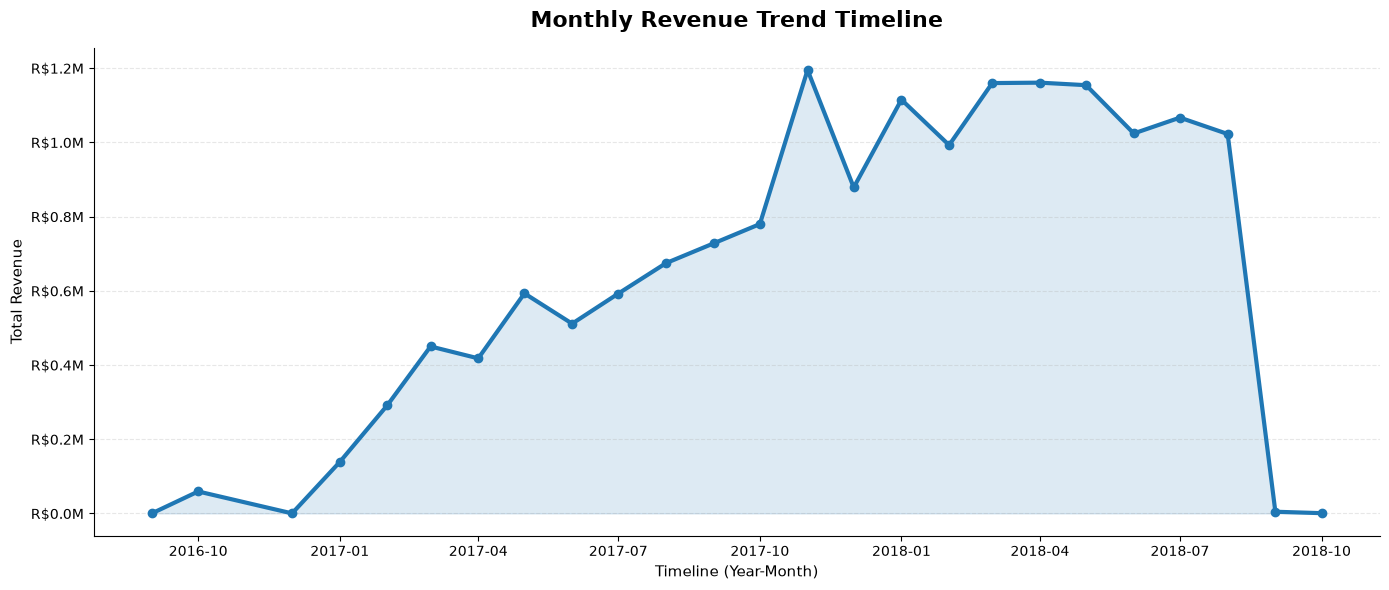

In [57]:
# ==================================================
# 4. Monthly Revenue Trend - Visualization
# ==================================================

# Initialize the plot layout using the Object-Oriented API
fig, ax = plt.subplots(figsize=(14, 6))

# Draw the main trend line with a professional width and clear markers
ax.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color="#1f77b4",
    linewidth=3,
    marker="o",
    markersize=6,
    label="Monthly Revenue"
)

# Add a subtle, elegant area fill under the trend line
ax.fill_between(
    monthly_revenue.index,
    monthly_revenue.values,
    color="#1f77b4",
    alpha=0.15
)

# --------------------------------------------------
# Axis Formatting & Styling (Done before final rendering)
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# X-Axis configuration: show ticks every 3 months using clean temporal formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Y-Axis configuration: Format values straight into Millions (R$ XX.XM) for a clean presentation
# Note: If you prefer your global function, you can use: FuncFormatter(currency_formatter)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R${x/1e6:.1f}M"))

# --------------------------------------------------
# Titles and Labels
# --------------------------------------------------
ax.set_title("Monthly Revenue Trend Timeline", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Timeline (Year-Month)", fontsize=11)
ax.set_ylabel("Total Revenue", fontsize=11)

# --------------------------------------------------
# Save and Export
# --------------------------------------------------
plt.tight_layout()

# Save the polished trend chart automatically to the charts directory
plt.savefig(
    CHARTS_DIR / "monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

Revenue shows an overall upward trend throughout the analyzed period, despite normal month-to-month fluctuations.

# Business Question 5: Which product categories generate the highest revenue?

This analysis identifies the primary product categories driving the platform's financial success, revealing consumer interest trends and inventory importance.

### Analytical Framework
Before writing the code, we structure our pipeline by answering three core questions:
1. **Which dataset?** `product_sales`.
2. **Which columns?** `product_category_name_english` and `price`.
   * *Note:* We use the English translated column created during the ETL process in Notebook 2, ensuring that global corporate stakeholders can easily read and interpret the results.
3. **Which metric?** Total revenue per category (calculated as the sum of `price`).

*Note for Stakeholders:* High-revenue categories highlight where the platform has a competitive advantage, giving commercial teams insights into which product sectors deserve larger vendor expansions.

In [58]:
# ==================================================
# 5. Revenue by Product Category - Data Preparation
# ==================================================

# Group by English category name and calculate total revenue, resetting index to keep columns accessible
category_revenue = product_sales.groupby("product_category_name_english")["price"].sum().reset_index()

# CLEANING STEP: Transform snake_case into elegant, professional title titles (e.g., health_beauty -> Health Beauty)
category_revenue["product_category_name_english"] = (
    category_revenue["product_category_name_english"]
    .str.replace("_", " ")
    .str.title()
)

# Filter for the top 10 after cleaning text
category_revenue = category_revenue.sort_values(by="price", ascending=False).head(10)

# Display the top 10 categories as a clean, structured table
display(
    category_revenue
    .set_index("product_category_name_english")[["price"]]
    .rename(columns={"price": "Total Revenue"})
)

,Total Revenue
product_category_name_english,
Health Beauty,1258681.34
Watches Gifts,1205005.68
Bed Bath Table,1036988.68
Sports Leisure,988048.97
Computers Accessories,911954.32
Furniture Decor,729762.49
Cool Stuff,635290.85
Housewares,632248.66
Auto,592720.11


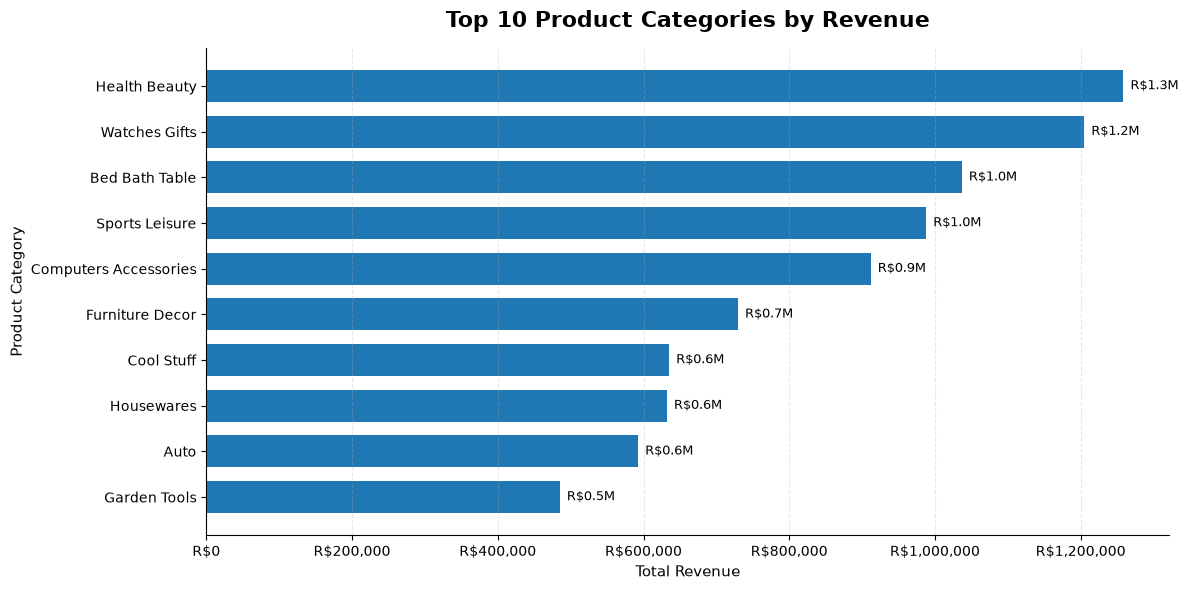

In [59]:
# ==================================================
# 5. Revenue by Product Category - Visualization
# ==================================================

# Initialize the plot layout for horizontal bars
fig, ax = plt.subplots(figsize=(12, 6))

# Draw horizontal bars using the clean DataFrame columns and setting height
bars = ax.barh(category_revenue["product_category_name_english"], category_revenue["price"], color="#1f77b4", height=0.7)

# --------------------------------------------------
# Axis Formatting & Styling (Done before adding text)
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()  # Display the highest revenue category at the top
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Apply local currency formatter for thousands to the horizontal numeric axis (X-axis)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R${x:,.0f}"))

# --------------------------------------------------
# Titles, Labels & Annotations
# --------------------------------------------------
ax.set_title("Top 10 Product Categories by Revenue", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Total Revenue", fontsize=11)
ax.set_ylabel("Product Category", fontsize=11)

# Add value labels next to each horizontal bar (formatted in Millions 'M' for cleaner look)
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"R${width/1e6:.1f}M",
        (width, bar.get_y() + bar.get_height()/2),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points"
    )

# --------------------------------------------------
# Save and Export
# --------------------------------------------------
plt.tight_layout()

# Save the polished horizontal chart automatically to the charts directory
plt.savefig(
    CHARTS_DIR / "revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

Health & Beauty generated the highest revenue among all product categories, followed by Watches & Gifts and Bed, Bath & Table.

These categories represent the company's strongest revenue drivers.

# Business Question 6: Who are the top 10 customers by total spending?

This analysis identifies the high-value customers (often referred to as "whales") who generated the highest total revenue for the e-commerce platform.

### Analytical Framework
Before writing the code, we structure our pipeline by answering three core questions:
1. **Which dataset?** `customer_sales`
2. **Which columns?** `customer_unique_id` and `payment_value`. 
   * *Note:* We use `customer_unique_id` instead of `customer_id`. In the Olist ecosystem, a customer receives a new `customer_id` for every individual order, whereas `customer_unique_id` represents the unique identity of the actual person across all their purchases. Tracking the unique identity is crucial for an accurate lifetime spending ranking.
3. **Which metric?** Total spending (calculated as the sum of `payment_value`).

In [60]:
# ==================================================
# 6. Top Customers by Spending - Data Preparation
# ==================================================

# Group by unique customer ID and calculate total spending
customer_revenue = customer_sales.groupby("customer_unique_id")["payment_value"].sum().reset_index()
customer_revenue = customer_revenue.sort_values(by="payment_value", ascending=False).head(10)

# Display the top 10 customers as a clean, structured table
display(
    customer_revenue
    .set_index("customer_unique_id")[["payment_value"]]
    .rename(columns={"payment_value": "Total Spending"})
)

,Total Spending
customer_unique_id,
0a0a92112bd4c708ca5fde585afaa872,13664.08
46450c74a0d8c5ca9395da1daac6c120,9553.02
da122df9eeddfedc1dc1f5349a1a690c,7571.63
763c8b1c9c68a0229c42c9fc6f662b93,7274.88
dc4802a71eae9be1dd28f5d788ceb526,6929.31
459bef486812aa25204be022145caa62,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
4007669dec559734d6f53e029e360987,6081.54
5d0a2980b292d049061542014e8960bf,4809.44


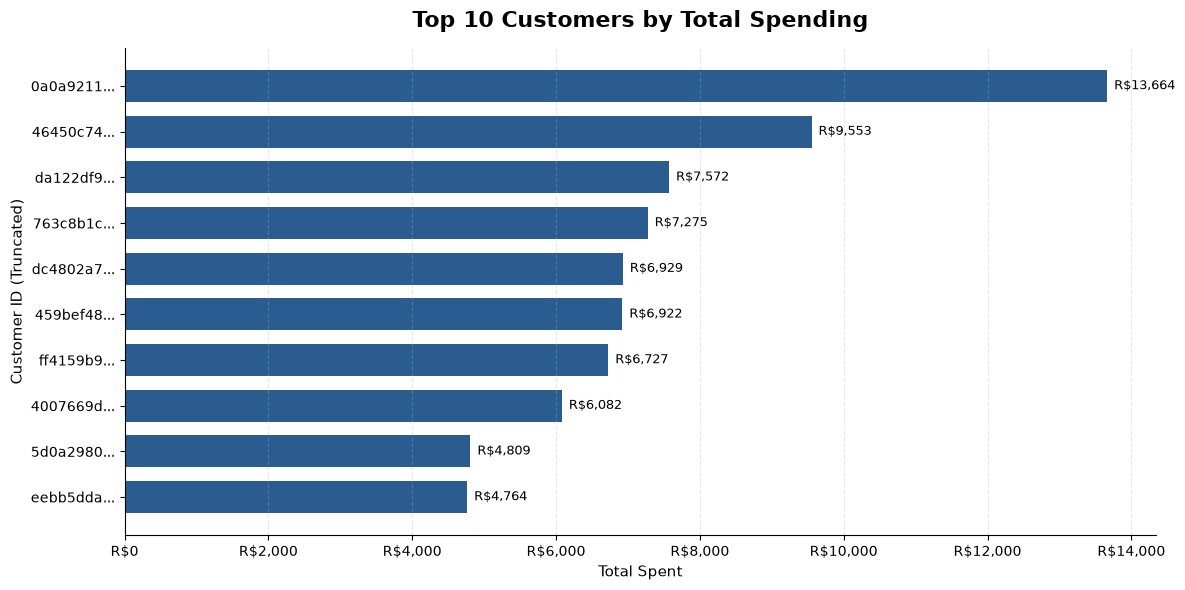

In [61]:
# ==================================================
# 6. Top Customers by Spending - Visualization
# ==================================================

# Initialize the plot layout with an appropriate size for horizontal bars
fig, ax = plt.subplots(figsize=(12, 6))

# Truncate customer IDs to the first 8 characters for cleaner visualization
customer_labels = customer_revenue["customer_unique_id"].str[:8] + "..."

# Draw horizontal bars with consistent project color and thickness
bars = ax.barh(customer_labels, customer_revenue["payment_value"], color="#2b5c8f", height=0.7)

# --------------------------------------------------
# Axis Formatting & Styling (Done before adding text)
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()  # Display the highest ranking customer at the top
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Apply local currency formatter for thousands (overriding the global 1M division)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R${x:,.0f}"))

# --------------------------------------------------
# Titles, Labels & Annotations
# --------------------------------------------------
ax.set_title("Top 10 Customers by Total Spending", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Total Spent", fontsize=11)
ax.set_ylabel("Customer ID (Truncated)", fontsize=11)

# Add formatted value labels (integers, no decimals) next to each horizontal bar
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"R${width:,.0f}",
        (width, bar.get_y() + bar.get_height()/2),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points"
    )

# --------------------------------------------------
# Save and Export
# --------------------------------------------------
plt.tight_layout()

# Save the polished chart automatically to the charts directory
plt.savefig(
    CHARTS_DIR / "top_customers_spending.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

Analyzing top-spending customers allows the business to identify high-value accounts (VIPs or "whales") that drive disproportionate revenue. Developing tailored loyalty programs, premium customer service, or exclusive offers for this elite segment can drastically boost customer retention and Lifetime Value (LTV). Additionally, tracking this metric helps monitor revenue concentration risk, ensuring the company maintains a healthy, well-distributed consumer base rather than over-relying on a tiny fraction of buyers.